# R8 — Figuras e interpretabilidad

Cierra las figuras del manuscrito que ningún otro notebook produce y aporta la
interpretabilidad que la revisión pide.

| Figura del paper | Origen |
|---|---|
| Fig. 4 — KS | `ks_report.csv` de R2 |
| Fig. 6 — PR-AUC por algoritmo y técnica | leaderboard de R4 |
| Fig. 7 — heatmap variante × técnica | leaderboard de R4 |
| Fig. 9 — importancia de variables | modelo ganador |

Sobre la importancia: la ganancia acumulada de XGBoost **no es aditiva** y no
sirve para explicar un caso concreto ante auditoría. Por eso aquí se calculan
además **importancia por permutación** sobre validation y, opcionalmente,
**valores SHAP**, que era la limitación 4 declarada en el manuscrito.

In [1]:
# Celda de arranque idéntica en todos los notebooks. Deja el kernel de SageMaker
# en un estado conocido: mismo directorio de trabajo, mismas semillas, mismas
# versiones. Si algo de esto cambia entre corridas, los resultados no son
# comparables aunque los notebooks sean los mismos.
import sys, os

AQUI = os.getcwd()                    # los notebooks y vishing_common.py conviven
if AQUI not in sys.path:
    sys.path.insert(0, AQUI)

import numpy as np
import pandas as pd
import vishing_common as vc

vc.set_all_seeds()                    # random, numpy y torch (+ cuDNN determinista)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

print("dataset:", vc.RAW_FILENAME, "(esquema", vc.DATASET_VERSION + ")")
print("bucket :", vc.BUCKET, "| prefijo:", vc.PREFIX)
print("seed   :", vc.SEED, "| split:", vc.SPLIT_MODE, "| política:", vc.FEATURE_POLICY)
print("xgboost se ejecutará en:", vc.xgb_device())
vc.check_versions()

dataset: biocatch_sinthetic_data_v3.csv (esquema v3)
bucket : poc-vishing | prefijo: v2
seed   : 42 | split: grouped | política: audited
xgboost se ejecutará en: cuda
AVISO: versiones fuera del rango declarado en requirements.txt:
paquete instalada   esperado    ok
xgboost     3.2.0 >=2.0,<2.2 False
  pip install -r requirements.txt


,paquete,instalada,esperado,ok
0,numpy,1.26.4,">=1.26,<2.1",True
1,pandas,2.2.3,">=2.1,<2.3",True
2,scipy,1.12.0,">=1.11,<1.15",True
3,sklearn,1.4.0,">=1.4,<1.6",True
4,imblearn,0.12.4,">=0.12,<0.13",True
5,xgboost,3.2.0,">=2.0,<2.2",False


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

cfg = vc.read_json(vc.P.feature_contract)
contract = cfg["contratos"][cfg["activo"]]
FEATS = contract["features"]

ganador = vc.read_json(vc.P.val_leaderboard.replace(
    "validation_leaderboard.csv", "ganador.json"))["ganador"]
env = vc.read_pickle(vc.P.model(ganador["data_type"], ganador["variante"],
                                ganador["technique"], ganador["ratio"]))
val = vc.read_parquet(vc.P.val)
Xv = val[FEATS].fillna(0)
yv = val[vc.TARGET].values
print(env)

/home/ec2-user/anaconda3/envs/JupyterSystemEnv/lib/python3.10/pickle.py:1718: UserWarning: [21:12:33] WARNING: /workspace/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


VishingModelWrapper(xgb_shallow/none/0, 44 features, thr=0.8464)


## 1. Importancia por ganancia acumulada (Fig. 9)

,feature,gain,gain_norm
0,call_overlap_duration_s,2072.630371,0.255598
1,is_new_beneficiary,985.359619,0.121515
2,max_hesitation_duration_s,726.459045,0.089587
3,dead_time_periods,451.612061,0.055693
4,transaction_amount_cop,431.987335,0.053273
5,segmented_typing_ratio,319.187653,0.039362
6,swipe_directional_variance,239.764404,0.029568
7,data_familiarity_score,218.877762,0.026992
8,time_to_transaction_s,209.734802,0.025865
9,avg_interkey_latency_ms,205.957016,0.025399


  escrito s3://poc-vishing/v2/06_results/feature_importance.csv  (43 filas)
  figura -> s3://poc-vishing/v2/07_figures/fig09_importancia_ganancia.png


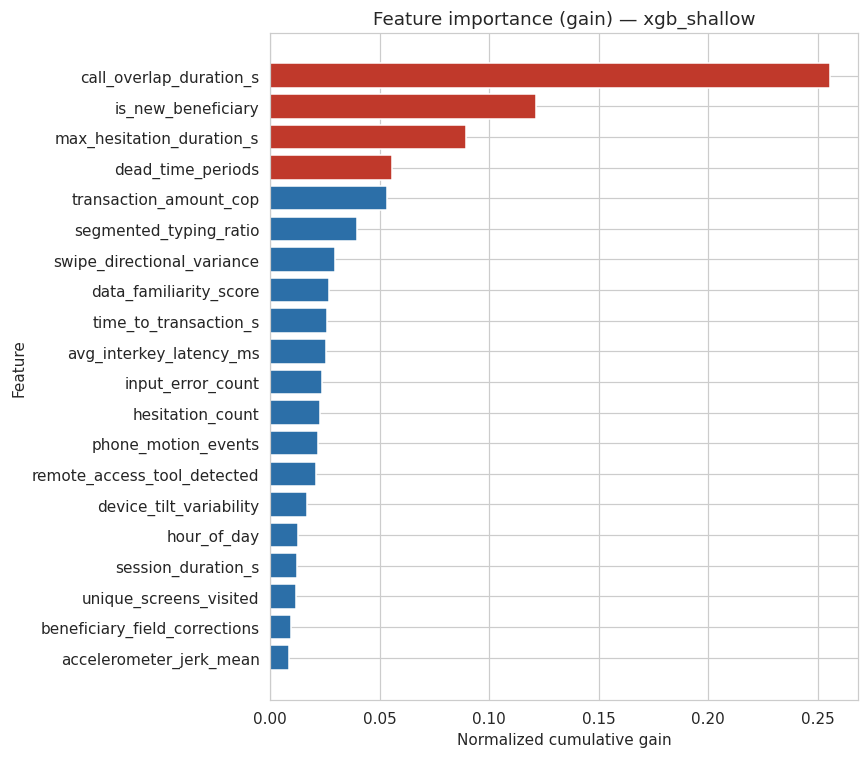

In [3]:
booster = env.model.get_booster() if hasattr(env.model, "get_booster") else None
if booster is not None:
    g = booster.get_score(importance_type="gain")
    idx = {("f%d" % i): f for i, f in enumerate(FEATS)}
    imp = (pd.DataFrame([{"feature": idx.get(k, k), "gain": v} for k, v in g.items()])
           .sort_values("gain", ascending=False).reset_index(drop=True))
    imp["gain_norm"] = imp.gain / imp.gain.sum()
else:
    imp = (pd.DataFrame({"feature": FEATS,
                         "gain": getattr(env.model, "feature_importances_", np.zeros(len(FEATS)))})
           .sort_values("gain", ascending=False).reset_index(drop=True))
    imp["gain_norm"] = imp.gain / max(imp.gain.sum(), 1e-12)

display(imp.head(20))
vc.write_csv(imp, vc.P.feature_importance)

t = imp.head(20).iloc[::-1]
corte = t.gain_norm.quantile(0.80)
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(t.feature, t.gain_norm,
        color=["#c0392b" if v >= corte else "#2c6fa8" for v in t.gain_norm])
ax.set_xlabel("Normalized cumulative gain")
ax.set_ylabel("Feature")
ax.set_title("Feature importance (gain) — %s" % ganador["variante"])
plt.tight_layout()
vc.save_figure(fig, vc.P.figure("fig09_importancia_ganancia.png"))
plt.show()

In [4]:
# Chequeo explícito de la afirmación de la Discusión VI-A del manuscrito
top15 = imp.head(15).feature.tolist()
print("¿phone_call_active está en el top 15?      ", "phone_call_active" in top15)
print("¿call_overlap_duration_s está en el top 15?", "call_overlap_duration_s" in top15)
print()
print("Contexto: en la v1, call_overlap_duration_s ocupaba el puesto 5 y ERA")
print("exactamente phone_call_active (r = 1,0000), de modo que el mismo proxy")
print("contextual entraba dos veces con distinto nombre. Sobre el dataset v3 son")
print("dos variables distintas (r = %.2f en validation): la binaria dice si hubo"
      % val.phone_call_active.corr(val.call_overlap_duration_s))
print("llamada y la continua cuánto cubrió de la sesión. Que ambas aparezcan alto")
print("ya no es un artefacto, pero sigue midiendo el mismo hecho: por eso R6")
print("evalúa la configuración 'all_sin_phone_call'.")
print()
fam = contract["families"]
etiqueta = {f: ("comportamental" if f in fam["behavioral"] else
                "contexto" if f in fam["context"] else "transacción")
            for f in FEATS}
imp["familia"] = imp.feature.map(etiqueta)
print("=== peso por familia en el top 15 ===")
print(imp.head(15).groupby("familia").gain_norm.agg(["count", "sum"]).round(4).to_string())

¿phone_call_active está en el top 15?       False
¿call_overlap_duration_s está en el top 15? True

Contexto: en la v1, call_overlap_duration_s ocupaba el puesto 5 y ERA
exactamente phone_call_active (r = 1,0000), de modo que el mismo proxy
contextual entraba dos veces con distinto nombre. Sobre el dataset v3 son
dos variables distintas (r = 0.63 en validation): la binaria dice si hubo
llamada y la continua cuánto cubrió de la sesión. Que ambas aparezcan alto
ya no es un artefacto, pero sigue midiendo el mismo hecho: por eso R6
evalúa la configuración 'all_sin_phone_call'.

=== peso por familia en el top 15 ===
                count     sum
familia                      
comportamental     10  0.3514
contexto            2  0.2766
transacción         3  0.2007


## 2. Importancia por permutación

Mide la caída real de PR-AUC al permutar cada variable **sobre validation**. A
diferencia de la ganancia, es comparable entre variables y no premia a las de
alta cardinalidad.

,feature,caida_pr_auc,std
0,call_overlap_duration_s,0.034872,0.001178
1,data_familiarity_score,0.030068,0.002463
2,hour_of_day,0.025380,0.001957
3,transaction_amount_cop,0.018455,0.002070
4,max_hesitation_duration_s,0.017132,0.001219
5,segmented_typing_ratio,0.008524,0.002202
6,unique_screens_visited,0.007313,0.001725
7,swipe_directional_variance,0.006758,0.001766
8,avg_interkey_latency_ms,0.006062,0.001019
9,transaction_attempted,0.005302,0.000768


  escrito s3://poc-vishing/v2/06_results/permutation_importance.csv  (44 filas)
  figura -> s3://poc-vishing/v2/07_figures/fig_importancia_permutacion.png


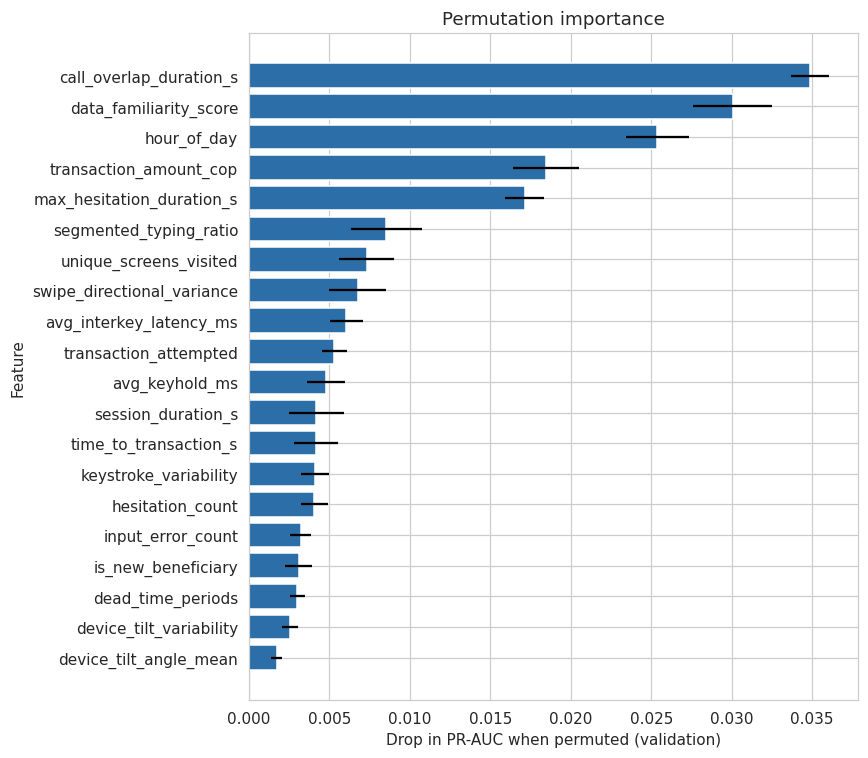

In [5]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score

Xv_ = env.scaler.transform(Xv.values) if env.scaler is not None else Xv.values


def pr_auc_scorer(est, X, y):
    """Scorer con la firma (estimator, X, y) que espera permutation_importance.

    Se define a mano en vez de usar make_scorer para no depender del argumento
    `response_method`, cuya firma cambió entre versiones de scikit-learn.
    """
    return average_precision_score(y, est.predict_proba(X)[:, 1])


r = permutation_importance(env.model, Xv_, yv, n_repeats=5,
                           random_state=vc.SEED, n_jobs=-1,
                           scoring=pr_auc_scorer)

perm = (pd.DataFrame({"feature": FEATS,
                      "caida_pr_auc": r.importances_mean,
                      "std": r.importances_std})
        .sort_values("caida_pr_auc", ascending=False).reset_index(drop=True))
display(perm.head(20))
vc.write_csv(perm, vc.P.permutation_importance)

t = perm.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(t.feature, t.caida_pr_auc, xerr=t["std"], color="#2c6fa8")
ax.set_xlabel("Drop in PR-AUC when permuted (validation)")
ax.set_ylabel("Feature")
ax.set_title("Permutation importance")
plt.tight_layout()
vc.save_figure(fig, vc.P.figure("fig_importancia_permutacion.png"))
plt.show()

In [6]:
# SHAP — opcional. Resuelve la limitación 4 declarada en el manuscrito.
CALCULAR_SHAP = True
if CALCULAR_SHAP:
    try:
        try:
            import shap
        except ImportError:
            import subprocess
            subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                            "shap>=0.44"], check=True)
            import shap
        muestra = Xv.sample(min(2000, len(Xv)), random_state=vc.SEED)
        expl = shap.TreeExplainer(env.model)
        sv = expl.shap_values(muestra)
        fig = plt.figure()
        shap.summary_plot(sv, muestra, max_display=20, show=False)
        vc.save_figure(plt.gcf(), vc.P.figure("fig_shap_summary.png"))
        plt.show()
    except ImportError:
        print("shap no instalado:  pip install shap")
    except Exception as e:
        print("SHAP no disponible para este modelo:", e)


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip


SHAP no disponible para este modelo: could not convert string to float: '[4.999379E-1]'


## 3. Comparación de modelos (Figs. 6 y 7)

modelos en el leaderboard: 260
  figura -> s3://poc-vishing/v2/07_figures/fig07_heatmap_original.png


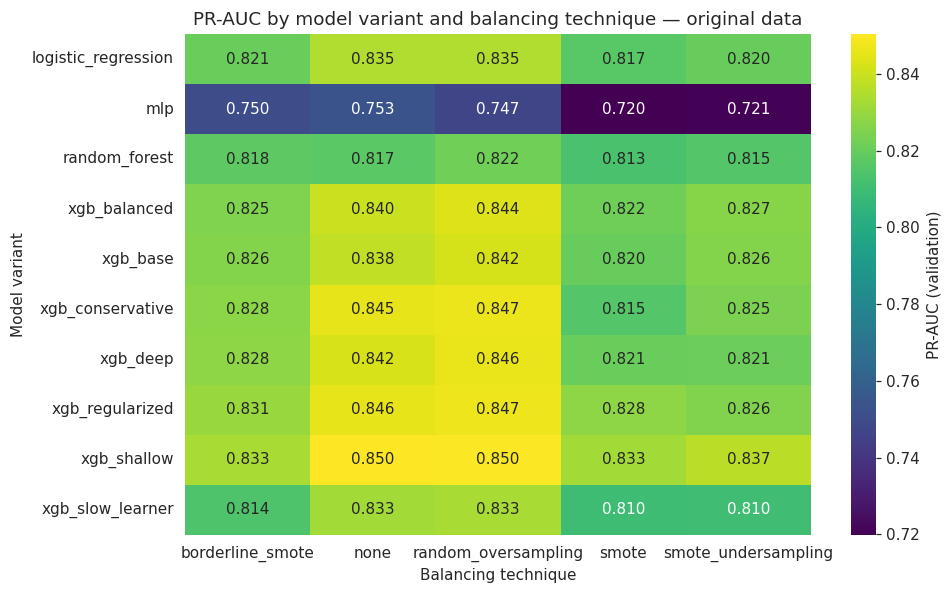

  figura -> s3://poc-vishing/v2/07_figures/fig07_heatmap_augmented.png


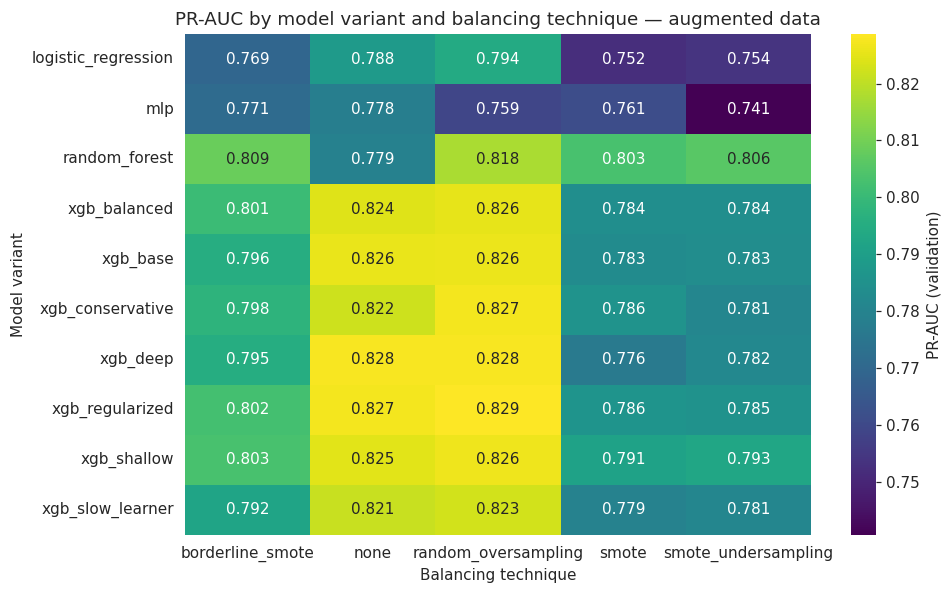

In [7]:
lb = vc.read_csv(vc.P.val_leaderboard)     # vía vc, no pd: la E/S vive en un solo sitio
print("modelos en el leaderboard:", len(lb))

for dt in lb.data_type.unique():
    sub = lb[lb.data_type == dt]
    piv = sub.pivot_table(index="variante", columns="technique",
                          values="pr_auc", aggfunc="max")
    fig, ax = plt.subplots(figsize=(9, 5.5))
    sns.heatmap(piv, annot=True, fmt=".3f", cmap="viridis", ax=ax,
                cbar_kws={"label": "PR-AUC (validation)"})
    ax.set_xlabel("Balancing technique"); ax.set_ylabel("Model variant")
    ax.set_title("PR-AUC by model variant and balancing technique — %s data" % dt)
    plt.tight_layout()
    vc.save_figure(fig, vc.P.figure("fig07_heatmap_%s.png" % dt))
    plt.show()

  figura -> s3://poc-vishing/v2/07_figures/fig06_pr_auc_por_tecnica.png


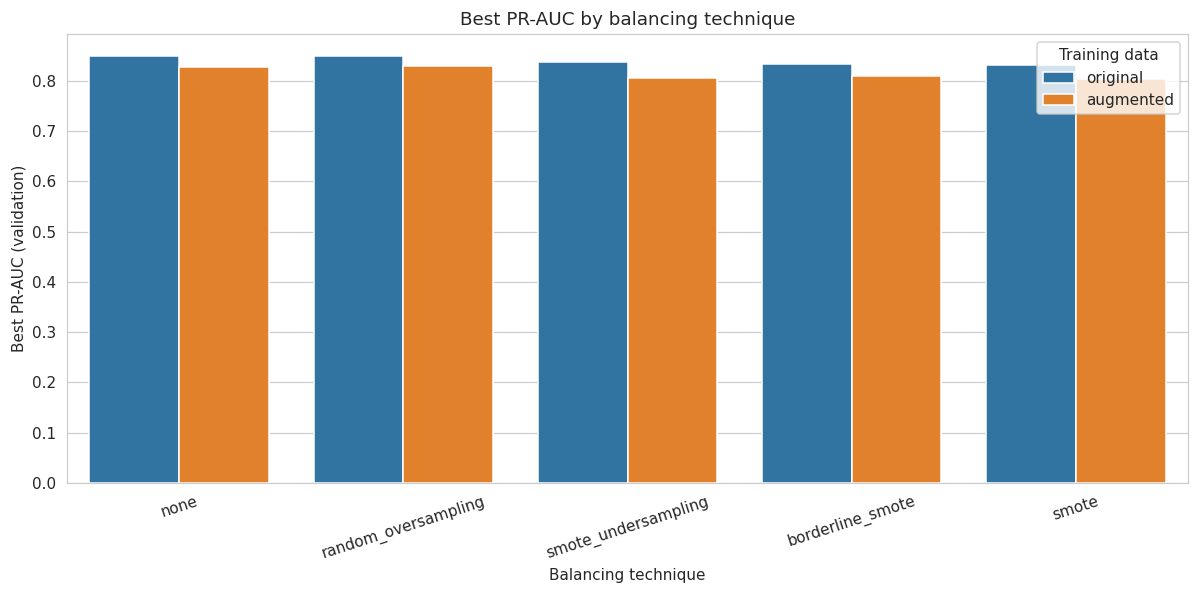

=== ¿sigue ganando el random oversampling una vez cerrada la fuga? ===
data_type            augmented  original
technique                               
borderline_smote        0.8087    0.8334
none                    0.8277    0.8504
random_oversampling     0.8287    0.8497
smote                   0.8031    0.8325
smote_undersampling     0.8059    0.8368

En la v1 el RO ganaba porque era la única técnica que copiaba los
positivos del test al entrenamiento (100 % medido). Si aquí ya no
domina, ese hallazgo del manuscrito queda explicado y debe reescribirse.


In [8]:
fig, ax = plt.subplots(figsize=(11, 5.5))
orden = lb.groupby("technique").pr_auc.max().sort_values(ascending=False).index
sns.barplot(data=lb, x="technique", y="pr_auc", hue="data_type",
            order=orden, estimator=max, errorbar=None, ax=ax)
ax.set_ylabel("Best PR-AUC (validation)"); ax.set_xlabel("Balancing technique")
ax.set_title("Best PR-AUC by balancing technique")
ax.legend(title="Training data")
plt.xticks(rotation=18)
plt.tight_layout()
vc.save_figure(fig, vc.P.figure("fig06_pr_auc_por_tecnica.png"))
plt.show()

print("=== ¿sigue ganando el random oversampling una vez cerrada la fuga? ===")
print(lb.groupby(["data_type", "technique"]).pr_auc.max().unstack(0).round(4).to_string())
print()
print("En la v1 el RO ganaba porque era la única técnica que copiaba los")
print("positivos del test al entrenamiento (100 % medido). Si aquí ya no")
print("domina, ese hallazgo del manuscrito queda explicado y debe reescribirse.")

## 4. Fidelidad del aumento (Fig. 4)

  figura -> s3://poc-vishing/v2/07_figures/fig04_ks.png


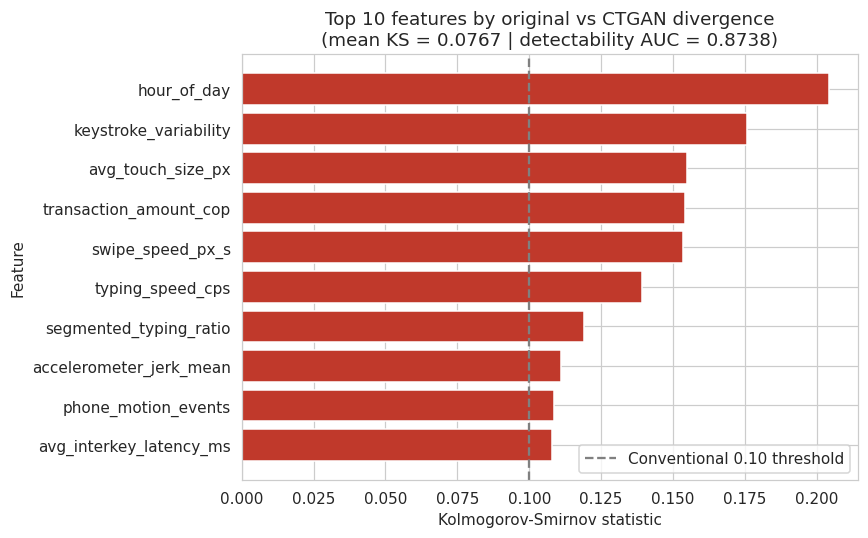

veredicto de detectabilidad: DUDOSO: distinguible, declarar como limitación


In [9]:
try:
    ks = vc.read_csv(vc.P.ks_report)
    det = vc.read_json(vc.P.detectability)
    utiles = ks[~ks.degenerada] if "degenerada" in ks.columns else ks
    t = utiles.head(10).iloc[::-1]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(t.feature, t.KS,
            color=["#c0392b" if v > 0.10 else "#2c6fa8" for v in t.KS])
    ax.axvline(0.10, ls="--", c="gray", label="Conventional 0.10 threshold")
    ax.set_xlabel("Kolmogorov-Smirnov statistic"); ax.set_ylabel("Feature")
    ax.set_title("Top 10 features by original vs CTGAN divergence\n"
                 "(mean KS = %.4f | detectability AUC = %.4f)"
                 % (utiles.KS.mean(), det["auc_media"]))
    ax.legend()
    plt.tight_layout()
    vc.save_figure(fig, vc.P.figure("fig04_ks.png"))
    plt.show()
    print("veredicto de detectabilidad:", det["veredicto"])
except Exception as e:
    print("R2 no ha corrido todavía; se omite. (%s)" % type(e).__name__)

## 5. Demostración de inferencia

In [12]:
import json

caso = val[val[vc.TARGET] == 1].iloc[0]
payload = caso[FEATS].to_dict()

print("=== predict_full() sobre una cadena JSON ===")
print(json.dumps(env.predict_full(json.dumps(payload)), indent=2, ensure_ascii=False))

print()
print("=== predict() y predict_proba_raw() sobre un dict ===")
print("  predict          :", env.predict(payload))
print("  predict_proba_raw:", env.predict_proba_raw(payload))

print()
print("=== lote de 5 ===")
for i, r in enumerate(env.predict_full(val[FEATS].head(5).to_dict("records"))):
    print("  obs %d: %-10s p=%.6f  thr=%.4f"
          % (i, r["label"], r["probability_vishing"], r["threshold_used"]))

print()
print("=== validación de entrada ===")
try:
    env.predict({k: payload[k] for k in list(payload)[:3]})
except ValueError as e:
    print("  falla explícitamente, como debe:", str(e)[:90])

=== predict_full() sobre una cadena JSON ===
{
  "label": "vishing",
  "prediction": 1,
  "probability_vishing": 0.996502161026001,
  "probability_legitimate": 0.0034978389739990234,
  "threshold_used": 0.8463879823684692,
  "threshold_fitted_on": "validation"
}

=== predict() y predict_proba_raw() sobre un dict ===
  predict          : 1
  predict_proba_raw: {'legitimate': 0.0034978389739990234, 'vishing': 0.996502161026001}

=== lote de 5 ===
  obs 0: legitimate p=0.006215  thr=0.8464
  obs 1: legitimate p=0.028193  thr=0.8464
  obs 2: legitimate p=0.011697  thr=0.8464
  obs 3: legitimate p=0.010285  thr=0.8464
  obs 4: legitimate p=0.028882  thr=0.8464

=== validación de entrada ===
  falla explícitamente, como debe: faltan features requeridas: ['keystroke_variability', 'segmented_typing_ratio', 'avg_touch


In [11]:
print("R8 completo. Figuras en", vc.P.figures)

R8 completo. Figuras en s3://poc-vishing/v2/07_figures
